DATA LOADING

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import pandas as pd
DATA_DIR = r"D:\deap-dataset\data_preprocessed_python"

def load_subject(subject_num):
    file_path = os.path.join(DATA_DIR, f's{subject_num:02d}.dat')
    with open(file_path, 'rb') as f:
        raw_data = pickle.load(f, encoding='latin1')
    eeg = raw_data['data'][:, :32, :]
    labels = raw_data['labels']
    return eeg, labels

In [2]:
all_eeg = []
all_labels = []
for i in range(1, 33):
    eeg, labels = load_subject(i)
    all_eeg.append(eeg)
    all_labels.append(labels)
    if i % 8 == 0: print(f"Loaded {i}/32 subjects...")

X_all = np.array(all_eeg, dtype='float32')
y_all = np.array(all_labels, dtype='float32')

Loaded 8/32 subjects...
Loaded 16/32 subjects...
Loaded 24/32 subjects...
Loaded 32/32 subjects...


EDA

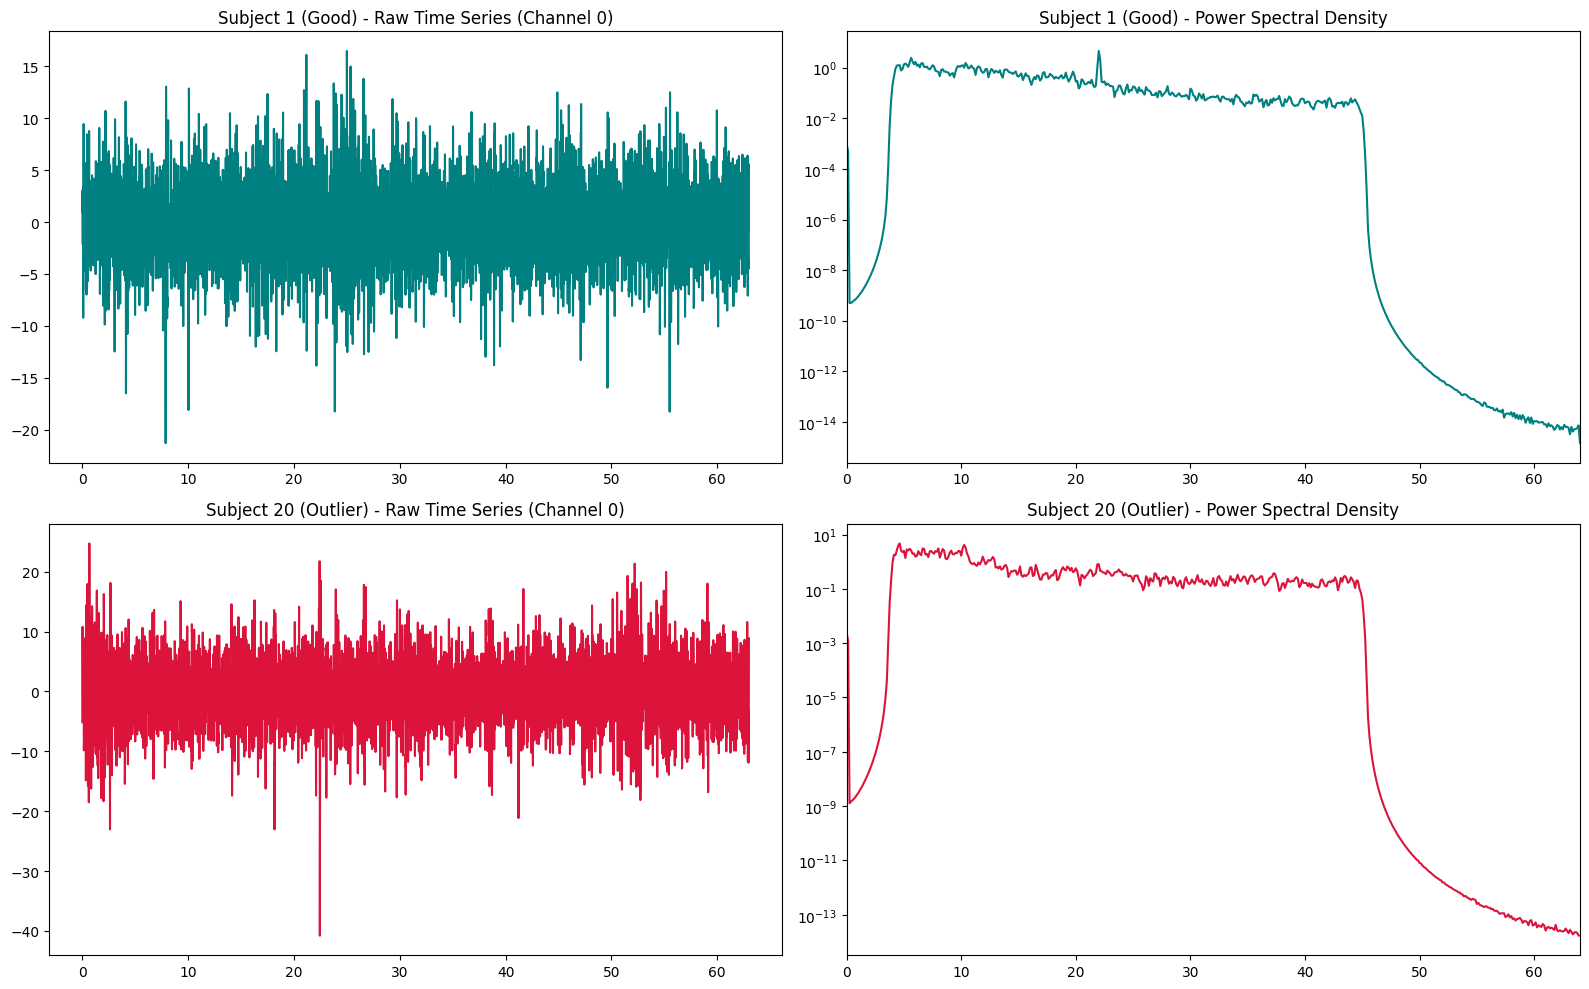

In [4]:
def plot_subject_comparison(subj_a=1, subj_b=20, trial_idx=0, chan_idx=0):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    subjects = [subj_a, subj_b]
    names = [f"Subject {subj_a} (Good)", f"Subject {subj_b} (Outlier)"]
    for i, subj in enumerate(subjects):
        sig = X_all[subj-1, trial_idx, chan_idx, :]
        time = np.arange(len(sig)) / 128.0
        
        axes[i, 0].plot(time, sig, color='crimson' if i==1 else 'teal')
        axes[i, 0].set_title(f"{names[i]} - Raw Time Series (Channel {chan_idx})")
        freqs, psd = signal.welch(sig, 128, nperseg=1024)
        axes[i, 1].semilogy(freqs, psd, color='crimson' if i==1 else 'teal')
        axes[i, 1].set_title(f"{names[i]} - Power Spectral Density")
        axes[i, 1].set_xlim(0, 64)
    plt.tight_layout()
    plt.show()
plot_subject_comparison(subj_a=1, subj_b=20)

In [5]:
# Drop Subject 4
subjects_to_drop = [3] # Index 3 is Subject 4
X_all = np.delete(X_all, subjects_to_drop, axis=0)
y_all = np.delete(y_all, subjects_to_drop, axis=0)

PREPROCESSING & FEATURE ENGINEERING

In [6]:
# Binarize Labels
y_valence_raw = y_all[:, :, 0]
y_flat_bin = (y_valence_raw > 5).astype(np.float32).reshape(-1)

In [8]:
# Zhao CNN Preprocessing
def apply_zhao_preprocessing(X):
    baseline = X[:, :, :, :384]
    task = X[:, :, :, 384:]
    baseline_mean = np.mean(baseline, axis=-1, keepdims=True)
    return task - baseline_mean
X_zhao = apply_zhao_preprocessing(X_all)
X_cnn_input = X_zhao.reshape(-1, 32, 7680)

In [9]:
# Pearson LSTM Preprocessing
num_trials = X_cnn_input.shape[0] 
X_lstm_input = np.zeros((num_trials, 32, 32), dtype=np.float32)
for i in range(num_trials):
    X_lstm_input[i] = np.corrcoef(X_cnn_input[i])

In [10]:
# Hybrid Preprocessing 
X_flat_hybrid = X_all.reshape(-1, 32, 8064)

In [11]:
sampling_rate = 128
eeg_bands = {'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}
deap_channels = ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Cz']

In [13]:
np.savez('preprocessed_data.npz', X_cnn=X_cnn_input, X_lstm=X_lstm_input, X_hybrid=X_flat_hybrid, y_bin=y_flat_bin)
print("Preprocessed data saved to 'preprocessed_data.npz'")

Preprocessed data saved to 'preprocessed_data.npz'
